In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report
import mne
from mne.decoding import CSP

In [6]:
# 1. Data Loading and Preprocessing Function
def load_and_epoch(subject_id: int, runs: list, tmin=0.5, tmax=3.5, l_freq=8.0, h_freq=30.0):
    """
    Loads specified runs for a subject, applies bandpass filter, and extracts 3-second epochs.
    """
    file_paths = mne.datasets.eegbci.load_data(subjects=subject_id, runs=runs, update_path=False)
    
    # Load each EDF and standardize channel names on ALL of them
    raws = []
    for f in file_paths:
        r = mne.io.read_raw_edf(f, preload=True)
        mne.datasets.eegbci.standardize(r)  # Strips trailing dots and cleans names
        raws.append(r)
    
    montage = mne.channels.make_standard_montage('standard_1005')
    
    raw = mne.concatenate_raws(raws)
    raw.set_montage(montage, match_case=False)
    
    # Universal preprocessing: 8-30 Hz Sensorimotor Band
    raw.filter(l_freq, h_freq, fir_design='firwin', skip_by_annotation='edge')
    
    # Extract events: T1 (Left Fist), T2 (Right Fist)
    events, event_dict = mne.events_from_annotations(raw, event_id={'T1': 1, 'T2': 2})
    
    # Epoching: 0.5s to 3.5s after the visual cue
    epochs = mne.Epochs(
        raw, 
        events, 
        event_id=event_dict, 
        tmin=tmin, 
        tmax=tmax, 
        baseline=None, 
        preload=True
    )
    
    X = epochs.get_data(copy=False)  # Shape: (trials, channels, timepoints)
    y = epochs.events[:, -1] - 1     # Map T1->0 (Left), T2->1 (Right)
    
    return epochs, X, y

In [7]:
# 2. Execution Setup (Subject 1)
SUBJECT = 1
TRAIN_RUNS = [3, 7]
TEST_RUNS = [11]

print(f"--- Loading Training Data (Runs {TRAIN_RUNS}) ---")
train_epochs, X_train, y_train = load_and_epoch(SUBJECT, TRAIN_RUNS)

print(f"\n--- Loading Testing Data (Run {TEST_RUNS}) ---")
test_epochs, X_test, y_test = load_and_epoch(SUBJECT, TEST_RUNS)

--- Loading Training Data (Runs [3, 7]) ---
Extracting EDF parameters from C:\Users\jason\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\jason\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R07.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Filtering raw data in 2 contiguous segments
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 

C:\Users\jason\AppData\Local\Temp\ipykernel_22636\3664225072.py:15: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mne.channels.make_standard_montage('standard_1005')



--- Loading Testing Data (Run [11]) ---
Extracting EDF parameters from C:\Users\jason\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R11.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)

Used Annotations descriptions: ['T1', 'T2']
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from 

C:\Users\jason\AppData\Local\Temp\ipykernel_22636\3664225072.py:15: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mne.channels.make_standard_montage('standard_1005')


In [8]:
# 3. Model Architecture (CSP + LDA)
# Using ledoit_wolf regularization for CSP stabilizes covariance estimation on small datasets
csp = CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)
lda = LinearDiscriminantAnalysis()
clf = Pipeline([("CSP", csp), ("LDA", lda)])

In [9]:
# 4. Training and Evaluation
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
class_balance = max(np.mean(y_test == 0), 1.0 - np.mean(y_test == 0))

print("\n=== Intra-Subject Results (Subject 1) ===")
print(f"Test Accuracy: {accuracy:.2%} / Chance level: {class_balance:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Left Fist", "Right Fist"]))

Computing rank from data with rank=None
    Using tolerance 0.00022 (2.2e-16 eps * 64 dim * 1.5e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.

=== Intra-Subject Results (Subject 1) ===
Test Accuracy: 80.00% / Chance level: 53.33%

Classification Report:
              precision    recall  f1-score   support

   Left Fist       0.83      0.71      0.77         7
  Right Fist       0.78      0.88      0.82         8

    accuracy                           0.80        15
   macro avg       0.81      0.79      0.80        15
weighted avg       0.80      0.80      0.80        15



NOTE: plot_patterns() is a legacy function. New code should use get_spatial_filter_from_estimator(clf, info=info).plot_patterns().


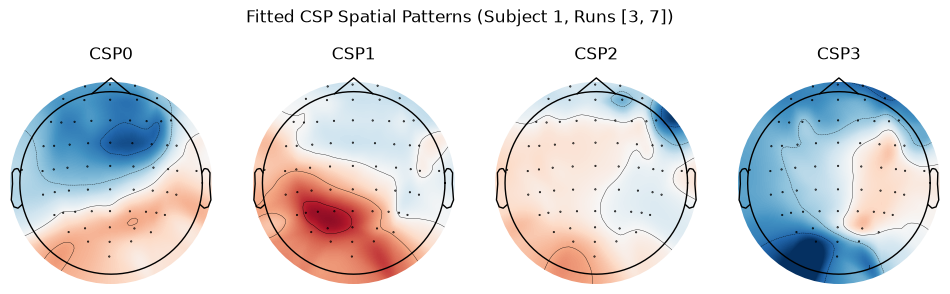

In [11]:
# 5. Visualization
# We extract the fitted CSP step from the pipeline to plot its spatial patterns
fitted_csp = clf.named_steps["CSP"]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
fitted_csp.plot_patterns(
    train_epochs.info, 
    components=np.arange(4), 
    axes=axes, 
    colorbar=False,
    show=False
)
fig.suptitle(f"Fitted CSP Spatial Patterns (Subject {SUBJECT}, Runs {TRAIN_RUNS})", y=1.05)
plt.show()